In [1]:
%matplotlib widget

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
spectrum_1 = pd.read_csv("Spectrum3s_1_noreg_gas_exp.csv")
spectrum_1 = spectrum_1.set_index('Name')
spectrum_2 = pd.read_csv("Spectrum3s_2_noreg_gas_exp.csv")
spectrum_2 = spectrum_2.set_index('Name')
spectrum_3 = pd.read_csv("Spectrum3s_3_noreg_gas_exp.csv")
spectrum_3 = spectrum_3.set_index('Name')
spectrum_4 = pd.read_csv("Spectrum3s_4_noreg_gas_exp.csv")
spectrum_4 = spectrum_4.set_index('Name')
spectrum_5 = pd.read_csv("Spectrum3s_5_noreg_gas_exp.csv")
spectrum_5 = spectrum_5.set_index('Name')

SNR_HA = pd.read_csv("SNR_HA_3s.csv")
SNR_HB = pd.read_csv("SNR_HB_3s.csv") 
SNR_NII_2 = pd.read_csv("SNR_NII_2_3s.csv") 
SNR_OIII_2 = pd.read_csv("SNR_OIII_2_3s.csv") 
SNR_SII_1 = pd.read_csv("SNR_SII_1_3s.csv") 
SNR_OI = pd.read_csv("SNR_OI_3s.csv")
SNR_HeII = pd.read_csv("SNR_HeII_3s.csv")

In [4]:
def Ke_OI(x):
    return 0.73/(x + 0.59) + 1.33

def SB12_1(x):
    return -1.22 + 1/(8.92*x+1.32)

#def SB12_2(x)

def error_ratio(err_1, err_2, flux_1, flux_2):
    e_1 = err_1/(flux_1*np.log(10))
    e_2 = err_2/(flux_2*np.log(10))
    print(np.sqrt((e_1)**2+(e_2)**2))
    return np.sqrt((e_1)**2+(e_2)**2)

def ratio_He(spectrum):
    HeII_HB = spectrum.loc['HeII4687', 'Flux']/spectrum.loc['Hbeta', 'Flux']
    NII_HA = spectrum.loc['[NII]6583', 'Flux']/spectrum.loc['Halpha', 'Flux']
    err_HeII_HB = error_ratio(spectrum.loc['HeII4687', 'Error_flux'], spectrum.loc['Hbeta', 'Error_flux'], spectrum.loc['HeII4687', 'Flux'], spectrum.loc['Hbeta', 'Flux'])
    err_NII_HA = error_ratio(spectrum.loc['[NII]6583', 'Error_flux'], spectrum.loc['Halpha', 'Error_flux'], spectrum.loc['[NII]6583', 'Flux'], spectrum.loc['Halpha', 'Flux']) 
    return HeII_HB, NII_HA, err_HeII_HB, err_NII_HA

def evaluation_SNR(SNR_HA, SNR_HB, SNR_NII, SNR_SII, SNR_OIII):
    if (SNR_HB < 0) and (SNR_OIII >= 3) and (SNR_HA >= 3) and (SNR_NII >= 3) and (SNR_SII >= 3):
        print('HB<0 but OIII>3')
        return True 
    elif (SNR_HB >= 3) and (SNR_OIII >= 3) and (SNR_HA >= 3) and (SNR_NII >= 3) and (SNR_SII >= 3):
        print('All ok')
        return True 
    else: 
        print('False')
        return False 

In [5]:
for i in range(5):
    print(i+1)
    evaluation_SNR(SNR_HA['SNR'][i], SNR_HB['SNR'][i], SNR_NII_2['SNR'][i], SNR_SII_1['SNR'][i], SNR_OIII_2['SNR'][i])
for i in range(5):
    if SNR_HeII['SNR'][i] >= 3:
        print(i+1, 'SNR(HeII) ok')
    else: print(i+1, 'SNR(HeII) X')

1
All ok
2
All ok
3
All ok
4
All ok
5
All ok
1 SNR(HeII) ok
2 SNR(HeII) X
3 SNR(HeII) X
4 SNR(HeII) X
5 SNR(HeII) ok


0.23799315173157207
0.01792477305258769
0.07118719805771324
0.045324090375529646


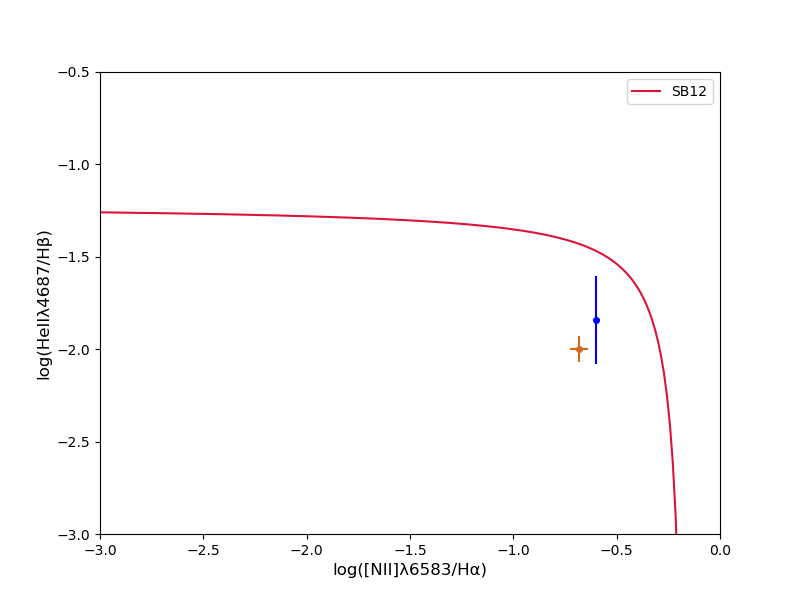

In [6]:
plt.figure(figsize=(8,6))

HeII_HB_1, NII_HA_1, err_HeII_HB_1, err_NII_HA_1 = ratio_He(spectrum_1)
#HeII_HB_2, NII_HA_2, err_HeII_HB_2, err_NII_HA_2 = ratio_He(spectrum_2)
#HeII_HB_3, NII_HA_3, err_HeII_HB_3, err_NII_HA_3 = ratio_He(spectrum_3)
#HeII_HB_4, NII_HA_4, err_HeII_HB_4, err_NII_HA_4 = ratio_He(spectrum_4)
HeII_HB_5, NII_HA_5, err_HeII_HB_5, err_NII_HA_5= ratio_He(spectrum_5)

plt.errorbar(x = np.log10(NII_HA_1), y = np.log10(HeII_HB_1), xerr = err_NII_HA_1, yerr = err_HeII_HB_1, color = 'blue', markersize = 4, marker = 'o')
#plt.errorbar(x = np.log10(NII_HA_2), y =np.log10(HeII_HB_2), xerr = err_NII_HA_2, yerr = err_HeII_HB_2,  color = 'green', markersize = 4, marker = 'o')
#plt.errorbar(x = np.log10(NII_HA_3), y = np.log10(HeII_HB_3), xerr = err_NII_HA_3, yerr = err_HeII_HB_3, color = 'm', markersize = 4, marker = 'o')
#plt.errorbar(x = np.log10(NII_HA_4), y = np.log10(HeII_HB_4), xerr = err_NII_HA_4, yerr = err_HeII_HB_4, color = 'orange', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(NII_HA_5), y =np.log10(HeII_HB_5), xerr = err_NII_HA_5, yerr = err_HeII_HB_5,  color = 'chocolate', markersize = 4, marker = 'o')

x = np.linspace(-3, -0.2, num=200)
x1 = np.linspace(-0.31, 1, num=200)

plt.plot(x, SB12_1(x), label = 'SB12', color = 'crimson')
#plt.plot(x1, Ke06(x1), label = 'Ke06')

plt.xlim(-3, 0)
plt.ylim(-3, -0.5)
plt.xlabel('log([NII]λ6583/Hα)', fontsize=12)
plt.ylabel('log(HeIIλ4687/Hβ)', fontsize=12)
plt.legend()
plt.savefig('BPT_HeII_3s', bbox_inches='tight') 